# Grain strucrture neighbourhood analysis

### Import modules

In [1]:
from upxo.ggrowth.mcgs import mcgs
from upxo.analysis.analysis2d import gsan2d
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


### Spawn a temporal grasin structue dataset

In [2]:
pxt = mcgs(input_dashboard='C:\\Development\\UPXO\\upxo_library\\src\\upxo\\interfaces\\user_inputs\\input_dashboard_profiling_alg202a.xls')
pxt.simulate()
pxt.detect_grains()

C:\Development\UPXO\upxo_library\src\upxo\interfaces\user_inputs
C:\Development\UPXO\upxo_library\src\upxo\interfaces\user_inputs\input_dashboard_profiling_alg202a.xls
Algo_hops details
(('200.0', 100),)
[False]





 Initiating Monte-Carlo simulation
     xmin, xmax, xinc: 0.0, 100.0, 1.0
     ymin, ymax, yinc: 0.0, 100.0, 1.0
     zmin, zmax, zinc: 0.0, 1000.0, 1.0
     No. of states: 5
     Dimensionality: 2
     Algorithm: 200.0 





-----------------------
[1. 1. 1.]
[1. 1. 1.]
[1. 1. 1.]
-----------------------
########################################
200.0
########################################
Using ALG-200: SA's SL NL-1 TP1 C2 unweighted Q-Pott's model:
|--------------- MC SIM RUN IN PROGRESS on: ALG200---------------|
GS temporal slice 0 stored
 ..............................
GS temporal slice 1 stored
 ..............................
GS temporal slice 2 stored
 ..............................
GS temporal slice 3 stored
 ..............................
GS temporal slice 4 sto

### Port the dataset into grain structure analysis modukle

In [3]:
gsan = gsan2d.from_gsstack_temporal(pxt, detect_grains=False, gsids=[], ispxtal=True, prechar=False, 
                                    find_neigh=False,
                                    npixels=False, npixels_gb=False, gb_length_px=False,
                                    eq_diameter=False, feret_diameter=False,
                                    perimeter=False, perimeter_crofton=False, aspect_ratio=True,
                                    compactness=False, solidity=True, morph_ori=False,
                                    circularity=False, eccentricity=True,
                                    euler_number=True, moments_hu=True,
                                    char_gb=False, get_grain_coords=True)

 Characterizing grain structure slice 0 
Extracting requested GS props across all available states
--------State value: 5 of 5
----------------------------------------
 Characterizing grain structure slice 1 
Extracting requested GS props across all available states
--------State value: 5 of 5
----------------------------------------
 Characterizing grain structure slice 2 
Extracting requested GS props across all available states
--------State value: 5 of 5
----------------------------------------
 Characterizing grain structure slice 3 
Extracting requested GS props across all available states
--------State value: 5 of 5
----------------------------------------
 Characterizing grain structure slice 4 
Extracting requested GS props across all available states
--------State value: 5 of 5
----------------------------------------
 Characterizing grain structure slice 5 
Extracting requested GS props across all available states
--------State value: 5 of 5
---------------------------------

### view all grain structure ids.
the gsidds will be same as keys in pxt.gs dataset

In [4]:
print(gsan.gsid)
print(pxt.gs.keys())

[0, 1, 2, 3, 4, 5, 6]
dict_keys([0, 1, 2, 3, 4, 5, 6])


### View the neighbour diictionary
This is expected to be empty

In [5]:
print(gsan.gsstack[5].neigh_gid)

None


### Create the neighbour dictionaries across all temporal slices

In [6]:
# gsan.find_neigh(gsids=None) # <-- NUMBA CRASHES JUPYTER KERNEL IF CALLED HERE.
# Instead, use below cell, manually calling the function after creation of gsan object.

In [7]:
# Mitigating numba crash by calling the function for each gsid separately.
for gsid in gsan.gsstack.keys():
    gsan.gsstack[gsid].find_neigh()


Extracting neigh list for all grains


Extracting neigh list for all grains


Extracting neigh list for all grains


Extracting neigh list for all grains


Extracting neigh list for all grains


Extracting neigh list for all grains


Extracting neigh list for all grains



In [8]:
"""
NUMBA CALL -- CRASHING AT THE MOMENT. Under investigation.
for gsid in gsan.gsstack.keys():
    gstslice = gsan.gsstack[gsid]
    gstslice.find_neigh_v2(p=1.0, include_central_grain=False,
                           throw_numba_dict=False, verbosity_nfids=1000)
"""

'\nNUMBA CALL -- CRASHING AT THE MOMENT. Under investigation.\nfor gsid in gsan.gsstack.keys():\n    gstslice = gsan.gsstack[gsid]\n    gstslice.find_neigh_v2(p=1.0, include_central_grain=False,\n                           throw_numba_dict=False, verbosity_nfids=1000)\n'

### Neighbour grain count distributions - temporal evolution
Lets see how the neighbour count distributions evolved over Monte-Carlo time. This could be used to:
1. characterize a 2D / 3D MC algorithm
2. relatuve study of 3D neighbour structure vs 2D slice neighbour structure

<Axes: ylabel='Count'>

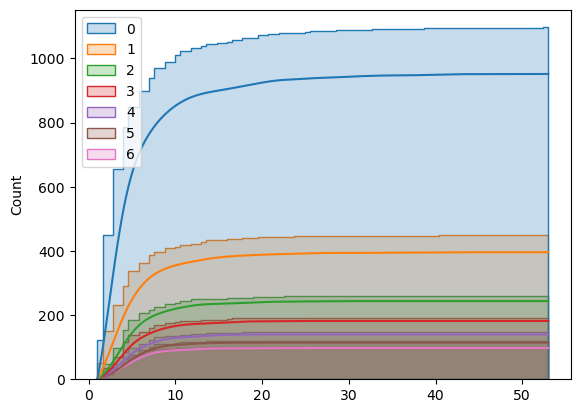

In [9]:
neigh_counts = {gsid: [len(n) for n in gsan.gsstack[gsid].neigh_gid.values()] for gsid in gsan.gsstack.keys()}
neigh_counts_df = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in neigh_counts.items()]))
sns.histplot(data=neigh_counts_df, kde=True, cumulative=True, element='step')

Text(0, 0.5, 'Max Neighbour Count')

<Figure size 1000x600 with 0 Axes>

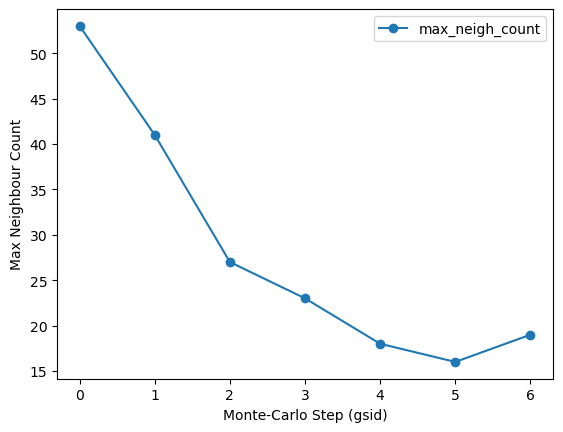

In [10]:
neigh_counts_max = {gsid: max([len(n) for n in gsan.gsstack[gsid].neigh_gid.values()]) for gsid in gsan.gsstack.keys()}
neigh_counts_max_df = pd.DataFrame.from_dict(neigh_counts_max, orient='index', columns=['max_neigh_count'])
plt.figure(figsize=(10,6))
neigh_counts_max_df.plot(marker='o')
plt.xlabel('Monte-Carlo Step (gsid)')
plt.ylabel('Max Neighbour Count')